In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import gzip
import csv
import os

In [2]:
# Reading the required files
class_labels_df = pd.read_csv('./data/class.tsv', sep='\t', header=None, names=['label'])

with gzip.open('./data/filtered.tsv.gz', 'rt') as f:
    gene_expression_df = pd.read_csv(f, sep='\t')
gene_expression_df.columns = gene_expression_df.columns.str.strip()

# with gzip.open('./data/columns_data.tsv.gz', 'rt') as f:
#     gene_metadata_df = pd.read_csv(f, sep='\t', header=None)
gene_metadata_df = pd.read_csv('./data/columns.tsv', sep='\t', header=None)

gene_metadata_df.columns = gene_metadata_df.iloc[0]

gene_metadata_df = gene_metadata_df[1:]
gene_info_df = gene_metadata_df[['ID', 'GeneSymbol']]

IDs for XBP1 and GATA3:
4404
4359


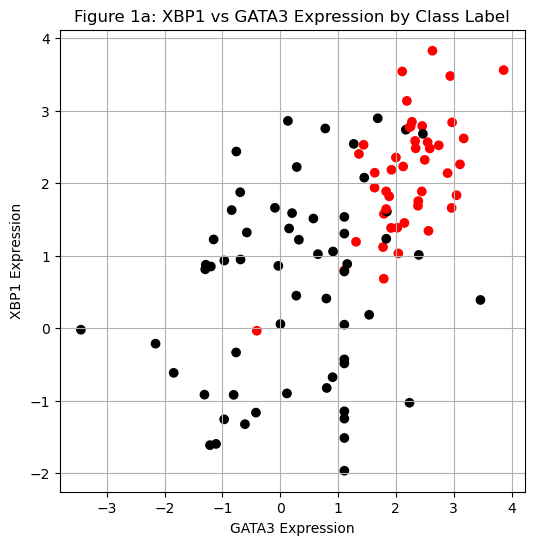

In [3]:
xbp1_id = gene_metadata_df[gene_metadata_df['GeneSymbol'] == 'XBP1']['ID'].values[0]
gata3_id = gene_metadata_df[gene_metadata_df['GeneSymbol'] == 'GATA3']['ID'].values[0]

# Printing the retrieved IDs
print("IDs for XBP1 and GATA3:")
print(xbp1_id)
print(gata3_id)

xbp1_expr = gene_expression_df[str(xbp1_id)]
gata3_expr = gene_expression_df[str(gata3_id)]


plt.figure(figsize=(6, 6))
# Using 'red' for label 1 (e.g., positive class) and 'black' for label 0 (e.g., negative class)
point_colors = ['black' if label == 0 else 'red' for label in class_labels_df['label']]

plt.scatter(gata3_expr, xbp1_expr, c=point_colors)

plt.xlabel('GATA3 Expression')
plt.ylabel('XBP1 Expression')
plt.title('Figure 1a: XBP1 vs GATA3 Expression by Class Label')
plt.grid(True)

plt.show()

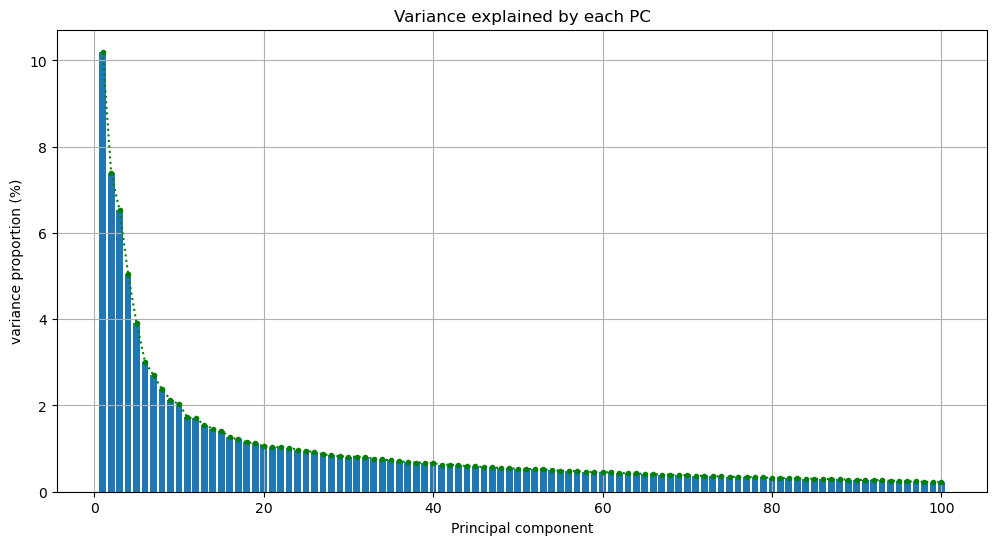

In [9]:
X = gene_expression_df.values
X_scaled = StandardScaler().fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)


plt.figure(figsize=(12, 6))

plt.bar(range(1, 101), pca.explained_variance_ratio_[:100] * 100)
plt.plot(range(1, 101), pca.explained_variance_ratio_[:100] * 100, marker='.', linestyle=':', color='green')
plt.xlabel('Principal component')
plt.ylabel('variance proportion (%)')
plt.title('Variance explained by each PC')
plt.grid(True)
plt.show()

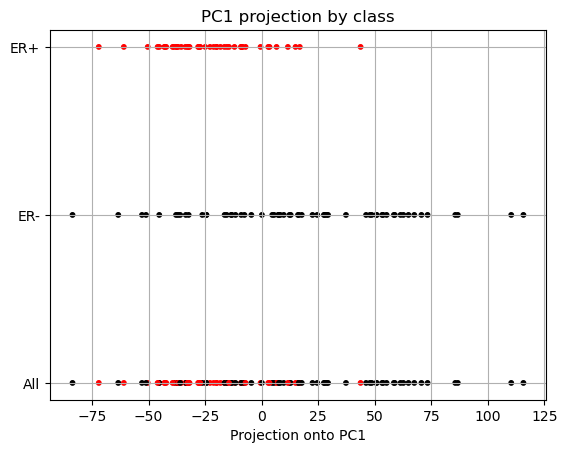

In [6]:
PC1 = X_pca[:, 0]

for i, label in enumerate(['All', 'ER-', 'ER+']):
    if label == 'All':
        indices = range(len(PC1))
    elif label == 'ER-':
        indices = class_labels_df[class_labels_df['label'] == 0].index
    else:
        indices = class_labels_df[class_labels_df['label'] == 1].index
    plt.scatter(PC1[indices], [i]*len(indices), c=np.array(point_colors)[indices], s=10)

plt.grid(True)
plt.title('PC1 projection by class')
plt.yticks([0, 1, 2], ['All', 'ER-', 'ER+'])
plt.xlabel('Projection onto PC1')
plt.show()